# Principal Component Analysis (PCA)

**PCA** is a dimensionality reduction technique that transforms complex datasets by converting correlated features into a smaller set of **uncorrelated components** while preserving maximum variance.

## Why PCA?
- 🗜️ **Data Compression**: Reduce features from 100+ to 2-3 while keeping 90%+ information
- 📊 **Visualization**: Transform high-dimensional data to 2D/3D for visual analysis  
- ⚡ **Efficiency**: Fewer features = faster training, less overfitting, lower computational cost
- 🔗 **Multicollinearity**: Decorrelates highly correlated features

## How PCA Works: 4 Steps

### Step 1️⃣: Standardize the Data
Scale features to mean=0, std=1 so all features contribute equally regardless of their units.

$$Z = \frac{X - \mu}{\sigma}$$

where $\mu$ = feature mean, $\sigma$ = feature standard deviation

### Step 2️⃣: Calculate Covariance Matrix
Measures how features relate and co-vary with each other.

$$cov(x_1, x_2) = \frac{\sum_{i=1}^{n}(x_{1i} - \bar{x}_1)(x_{2i} - \bar{x}_2)}{n-1}$$

### Step 3️⃣: Find Eigenvectors & Eigenvalues
From covariance matrix, compute eigenvectors (directions) and eigenvalues (importance).

$$AX = \lambda X$$

- **Eigenvectors**: Define principal component directions
- **Eigenvalues**: Measure variance captured (importance ranking)

### Step 4️⃣: Select & Transform
- Select top k components with highest eigenvalues (capture 95%+ variance)
- Project data onto these components to reduce dimensions

---

## Implementation in Python

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Sample dataset
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]
}

df = pd.DataFrame(data)
print("Dataset:")
print(df)

Dataset:
   Height  Weight  Age  Gender
0     170      65   30       1
1     165      59   25       0
2     180      75   35       1
3     175      68   28       1
4     160      55   22       0
5     172      70   32       1
6     168      62   27       0
7     177      74   33       1
8     162      58   24       0
9     158      54   21       0


In [14]:
# Standardize the data (Step 1)
X = df.drop('Gender', axis=1)
y = df['Gender']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nOriginal data range: Height", X['Height'].min(), "-", X['Height'].max())
print("Scaled data mean:", X_scaled.mean(axis=0).round(2))
print("Scaled data std:", X_scaled.std(axis=0).round(2))


Original data range: Height 158 - 180
Scaled data mean: [ 0. -0.  0.]
Scaled data std: [1. 1. 1.]


In [15]:
# Apply PCA (Steps 2-4)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nPCA Results:")
print(f"PC1 variance explained: {pca.explained_variance_ratio_[0]:.1%}")
print(f"PC2 variance explained: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance preserved: {pca.explained_variance_ratio_.sum():.1%}")
print("\nFeature contributions to PCs:")
print(pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X.columns))


PCA Results:
PC1 variance explained: 97.9%
PC2 variance explained: 1.8%
Total variance preserved: 99.6%

Feature contributions to PCs:
             PC1       PC2
Height  0.575755 -0.680522
Weight  0.581400 -0.048971
Age     0.574875  0.731090


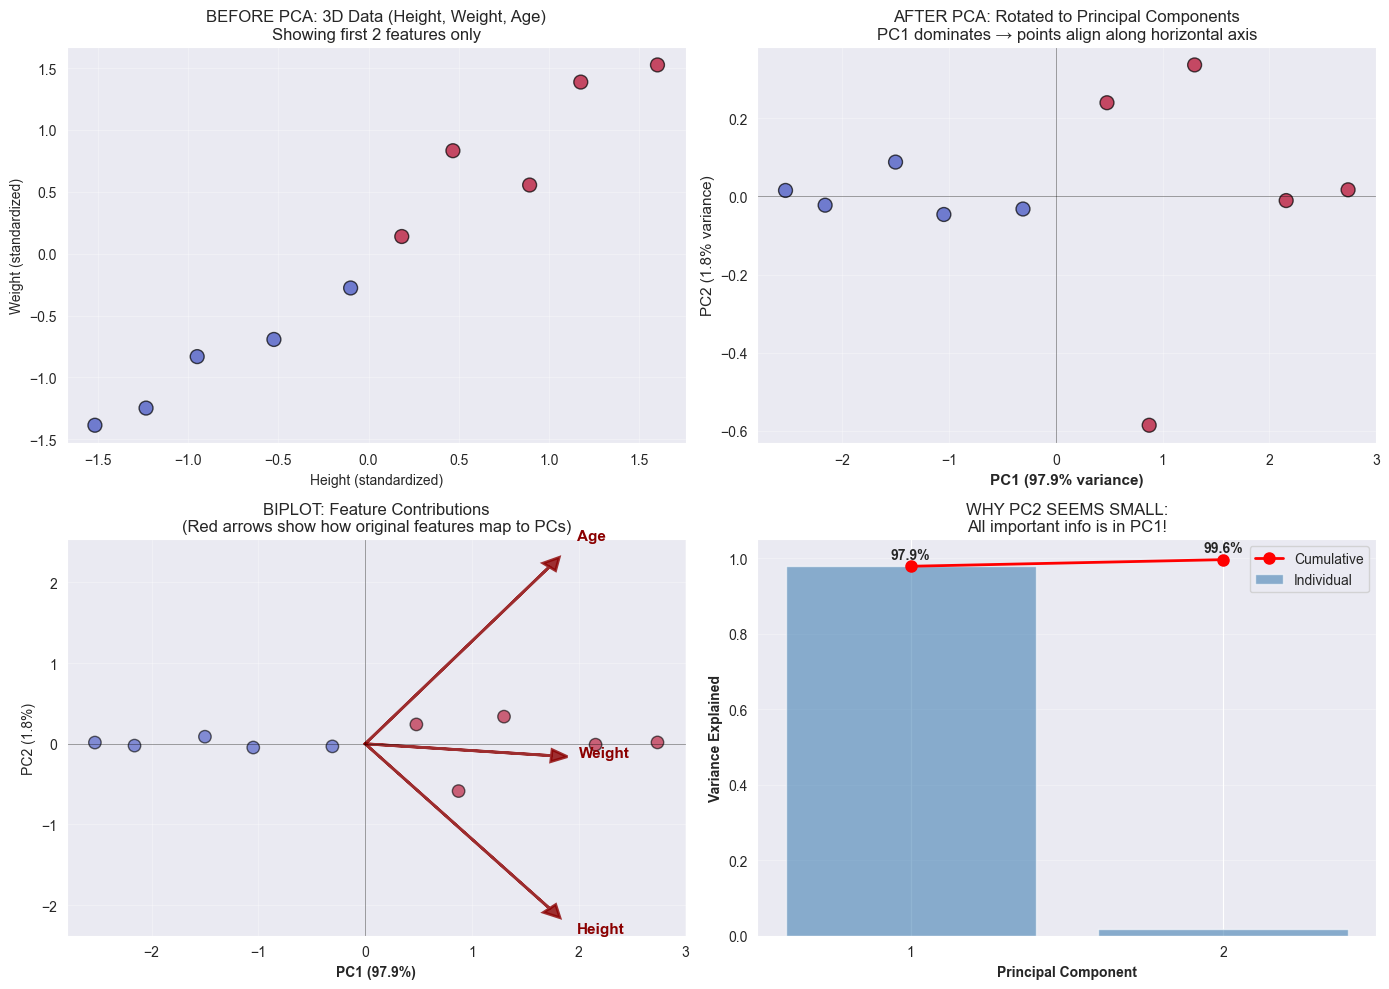

In [17]:
# Visualization: Before & After PCA with better explanation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ===== Row 1: Scatter plots =====
# Before PCA: First 2 features (original space)
axes[0, 0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm', s=100, edgecolor='k', alpha=0.7)
axes[0, 0].set_xlabel('Height (standardized)')
axes[0, 0].set_ylabel('Weight (standardized)')
axes[0, 0].set_title('BEFORE PCA: 3D Data (Height, Weight, Age)\nShowing first 2 features only')
axes[0, 0].grid(True, alpha=0.3)

# After PCA: First 2 PCs (new space)
axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', s=100, edgecolor='k', alpha=0.7)
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
axes[0, 1].set_title('AFTER PCA: Rotated to Principal Components\nPC1 dominates → points align along horizontal axis')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=0, color='k', linewidth=0.5, alpha=0.5)
axes[0, 1].axvline(x=0, color='k', linewidth=0.5, alpha=0.5)

# ===== Row 2: Detailed visualizations =====
# Biplot: Show how original features map to PCs
ax = axes[1, 0]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', s=80, edgecolor='k', alpha=0.6)

# Plot feature vectors (loadings scaled up for visibility)
scale_factor = 3
for i, feature in enumerate(X.columns):
    ax.arrow(0, 0, 
             pca.components_[0, i] * scale_factor, 
             pca.components_[1, i] * scale_factor,
             head_width=0.15, head_length=0.15, fc='darkred', ec='darkred', alpha=0.8, linewidth=2)
    ax.text(pca.components_[0, i] * scale_factor * 1.15,
            pca.components_[1, i] * scale_factor * 1.15,
            feature, fontsize=11, fontweight='bold', color='darkred')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('BIPLOT: Feature Contributions\n(Red arrows show how original features map to PCs)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.5)
ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.5)

# Variance breakdown
ax = axes[1, 1]
components = np.arange(1, len(pca.explained_variance_ratio_) + 1)
variance = pca.explained_variance_ratio_
cumsum = np.cumsum(variance)

ax.bar(components, variance, alpha=0.6, label='Individual', color='steelblue')
ax.plot(components, cumsum, 'ro-', linewidth=2, markersize=8, label='Cumulative')
ax.set_xlabel('Principal Component', fontweight='bold')
ax.set_ylabel('Variance Explained', fontweight='bold')
ax.set_title('WHY PC2 SEEMS SMALL:\nAll important info is in PC1!')
ax.set_xticks(components)
ax.set_ylim([0, 1.05])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Annotate cumulative percentage
for i, (v, c) in enumerate(zip(variance, cumsum)):
    ax.text(i + 1, c + 0.02, f'{c:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---

## ✅ Advantages of PCA

| Advantage | Benefit |
|-----------|---------|
| **Multicollinearity** | Converts correlated features into uncorrelated PCs |
| **Noise Reduction** | Low-variance components are often noise → removing them cleans data |
| **Data Compression** | 100 features → 10 PCs with 95% info = 90% storage/speed improvement |
| **Outlier Detection** | Points far from origin in PC space are outliers |
| **Visualization** | Transform any high-D data to 2D/3D for visual analysis |

## ❌ Disadvantages of PCA

| Limitation | Impact |
|-----------|--------|
| **Interpretation** | PCs are linear combinations of all features (hard to explain) |
| **Scaling Sensitive** | Must standardize first or high-scale features dominate |
| **Information Loss** | Keeping too few PCs loses important minority variance patterns |
| **Linearity** | Only works for linear relationships; fails on curved/nonlinear data |
| **Computational Cost** | Slow on very large datasets (millions of samples/features) |

## Understanding the PCA Plot

### Why does the "After PCA" plot look like a line?

**This is actually expected!** Here's why:

- **PC1 explains 97.9%** of all variance → contains almost all information
- **PC2 explains only 1.8%** of variance → adds almost nothing

**Real-world analogy:** Imagine looking at a data cloud from different angles:
- If you tilt your head to the PC1 direction, you see most of the "spread" (97.9%)
- If you tilt to PC2 direction, you see almost no spread (1.8%)

### What does this tell us?

✅ **Good news:** 3 original features compressed to 1 PC with 97.9% information!
- Instead of tracking Height, Weight, Age separately → track PC1
- Simpler model, faster computation

### What the plots mean:

1. **Top-left (Before)**: Original 3D data shown in 2D (Height vs Weight only)
2. **Top-right (After)**: Same data rotated to PC space (PC1 vs PC2)
   - **Points line up horizontally** = PC1 dominates
   - **Small vertical spread** = PC2 contributes little
   
3. **Biplot (Bottom-left)**: Red arrows show which original features matter:
   - All arrows point mostly **right** → Height, Weight, Age all contribute to PC1
   - Arrows point **up/down slightly** → minimal PC2 contribution

4. **Variance chart (Bottom-right)**: Shows cumulative information
   - PC1 alone captures 97.9% ✓
   - PC2 adds only 1.8% more ✓

## 🌍 Real-World Applications

| Domain | Use Case |
|--------|----------|
| **Face Recognition** | Eigenfaces: reduce facial images from 10,000+ pixels → 50 dimensions |
| **Genomics** | Analyze 20,000+ genes simultaneously in reduced space |
| **Stock Market** | Reduce 500 stock features → 10 PCs capturing market patterns |
| **Image Compression** | Keep 90% of image info with 50% fewer pixels |
| **Customer Segmentation** | Reduce 100 behavioral features → visualize 2D customer groups |

## 🎯 Quick Decision Guide

**Use PCA when:**
- ✅ You have 10+ correlated features
- ✅ Computational speed matters
- ✅ You need 2D/3D visualization
- ✅ You want to remove noise

**Don't use PCA when:**
- ❌ Features are already independent
- ❌ You need to explain feature importance
- ❌ Data has nonlinear relationships
- ❌ You have very few features (< 5)